In [1]:
# Base Imports
import os,sys
import numpy as np
import matplotlib.pyplot as plt
import scipy

#Skyllh Imports
from skyllh.core.config import Config
from skyllh.datasets.i3.PublicData_10y_ps import create_dataset_collection
# For power law source model
from skyllh.analyses.i3.publicdata_ps.time_integrated_ps import create_analysis as create_analysis_with_simple_pl
# For custom source model
from skyllh.analyses.i3.publicdata_ps.time_integrated_ps_function_energy_spectrum  import create_analysis as create_analysis_with_custom_mdl

from skyllh.core.source_model import PointLikeSource
from skyllh.core.random import RandomStateService
from skyllh.core.utils.analysis import create_trial_data_file
from skyllh.core.timing import TimeLord
from skyllh.core.utils.analysis import extend_trial_data_file
from skyllh.core.parameters import Parameter

from concurrent.futures import ProcessPoolExecutor, as_completed

import matplotlib as mpl
font = {'size'   : 25}
mpl.rc('font', **font) 

In [2]:
import skyllh

In [3]:
os.getcwd()

'/Users/aadesai1/Desktop/In_use/public_IceCube_data/justin_paper_checks'

In [4]:
sources = [["Tycho",6.3208,64.15],       #0, dec +64° 09’
           ["CassA",350.9,58.81],       #1, dec +58° 48’ 41”
           ["IC443",94.3,22.52],       #2, dec +22° 31’ 05”
           ["RX_J1713",17.23,- 39.77],  #3, dec -39° 46’
           ["SN1006",225.7,- 41.95],    #4, dec -41° 57’
           ["W44",18.94,- 41.95],    #4, dec -41° 57’
           ["Code_test",0.01,0.01]]    #6, dec 0



# Default = Tycho
test_source = 4#5
source_tested = sources[test_source]

# Optional Parameters for possible tests:
kde_used=False 
#kde_used=True
source_mdl_used = "PL"
#source_mdl_used = "custom" 
#minimizer_used='minuit'
minimizer_used='LBFGS'

In [5]:
# Make possible directories
if os.path.isdir(f'Image_plots')!=True:
    os.mkdir(f'Image_plots')
if os.path.isdir(f'Data_files')!=True:
    os.mkdir(f'Data_files')
if os.path.isdir(f'Cache')!=True:
    os.mkdir(f'Cache')

Create a configuration

In [6]:
help(Config)

Help on class Config in module skyllh.core.config:

class Config(builtins.dict)
 |  Config() -> None
 |  
 |  This class, derived from dict, holds the a local configuration state.
 |  
 |  Method resolution order:
 |      Config
 |      builtins.dict
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __init__(self) -> None
 |      Initializes a new Config instance holding the base configuration.
 |  
 |  disable_tracing(self)
 |      Disables the tracing mode of SkyLLH.
 |      
 |      Returns
 |      -------
 |      self : instance of Config
 |          The updated instance of Config.
 |  
 |  enable_tracing(self)
 |      Enables the tracing mode of SkyLLH.
 |      
 |      Returns
 |      -------
 |      self : instance of Config
 |          The updated instance of Config.
 |  
 |  get_wd(self)
 |      Retrieves the absolute path to the working directory as configured in
 |      this configuration.
 |      
 |      Returns
 |      -------
 |      wd : str
 |          Th

In [7]:
cfg = Config()
cfg.set_ncpu(16)
cfg

{'multiproc': {'ncpu': 16},
 'logging': {'log_level': 'INFO',
  'log_format': '%(asctime)s %(processName)s %(name)s %(levelname)s: %(message)s',
  'enable_tracing': False},
 'project': {'working_directory': '.'},
 'repository': {'base_path': None, 'download_from_origin': True},
 'units': {'internal': {'angle': Unit("rad"),
   'energy': Unit("GeV"),
   'length': Unit("cm"),
   'time': Unit("s")},
  'defaults': {'fluxes': {'angle': Unit("rad"),
    'energy': Unit("GeV"),
    'length': Unit("cm"),
    'time': Unit("s")}}},
 'datafields': {'run': 4,
  'ra': 4,
  'dec': 4,
  'ang_err': 4,
  'time': 4,
  'log_energy': 4,
  'true_ra': 8,
  'true_dec': 8,
  'true_energy': 8,
  'mcweight': 8},
 'caching': {'pdf': {'MultiDimGridPDF': False}}}

Load the public Dataset

In [8]:
dsc = create_dataset_collection(
    cfg=cfg,
    base_path='/Users/aadesai1/Desktop/In_use/public_IceCube_data/10yr_public_pstracks')

In [9]:
#Checking data
dsc.dataset_names

['IC40',
 'IC59',
 'IC79',
 'IC86_I',
 'IC86_II',
 'IC86_II-VII',
 'IC86_III',
 'IC86_IV',
 'IC86_V',
 'IC86_VI',
 'IC86_VII']

In [10]:
datasets = dsc['IC40', 'IC59', 'IC79', 'IC86_I', 'IC86_II-VII']
if source_tested[0]=='Code_test':
    datasets = dsc[ 'IC59', 'IC79', 'IC86_I', 'IC86_II', 'IC86_III', 'IC86_IV', 'IC86_V', 'IC86_VI'] 
    # 8 years of data matching https://arxiv.org/pdf/1811.07979

In [11]:
# To check parameters for create_analysis
# help(create_analysis)
name_used= source_tested[0]
ra_used = source_tested[1]
dec_used = source_tested[2]

source = PointLikeSource(name=name_used,ra=np.deg2rad(ra_used), dec=np.deg2rad(dec_used))

In [12]:
source_tested

['SN1006', 225.7, -41.95]

In [13]:
if os.path.isdir(f'Image_plots/{name_used}/')!=True:
    os.mkdir(f'Image_plots/{name_used}/')

In [14]:
print("Energy Model: ",source_mdl_used)
if source_mdl_used=="PL":
    print("Simple Power Law Used")
    E_refrence_val =1000.0
    spectral_index =2.0
    
else:
    print("Custom Model Used")
    print("Setup to be updated in future version")


Energy Model:  PL
Simple Power Law Used


In [15]:
def make_ana(cfg,datasets,source,E_refrence_val,spectral_index,kde_used,minimizer_used):
    if source_mdl_used=="PL":
        ana = create_analysis_with_simple_pl(cfg=cfg, 
                      datasets=datasets, 
                      source=source,
                      refplflux_Phi0=1,             #Flux normalization for model
                      refplflux_E0=E_refrence_val,          # E_0
                      refplflux_gamma=spectral_index,          # spectral index is kept FREE for likelihood
                      ns_seed=100.0,                # Initial seed
                      ns_min=0.0, 
                      ns_max=1000.0, 
                      gamma_seed=spectral_index,               # Initial seed
                      kde_smoothing=kde_used,           # KDE!
                      minimizer_impl=minimizer_used,        # LBFGS or minuit
                      compress_data=True,            
                      keep_data_fields=None,         # additional data field names that should get kept
                      evt_sel_delta_angle_deg=10,    # angle in degrees for the event selection optimization
                      construct_sig_generator=True,
                      tl=None,                       # TimeLord instance to use to time
                      ppbar=None,                    # ProgressBar 
                      logger_name=None)
    else:
        print("Custom Model Used")
        print("Setup to be updated in future version")
    return ana

ana = make_ana(cfg,datasets,source,E_refrence_val,spectral_index,kde_used,minimizer_used)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 170/170 [00:00<00:00, 556.89it/s]


In [16]:
ana.energy_range = (1e2,1e9)

In [17]:
# Just to check for custom model:
#ana.shg_mgr.get_fluxmodel_by_src_idx(0).energy_profile(E=10**6).squeeze()*10**6*10**6


In [18]:
#np.log10(eng_interst[np.argmax(nu_flux_val)])

# Calculating the sensitivity/Differential Sensitivity


### First Generate Background Trials

In [19]:
trials_directory = f'Cache/{name_used}_trials/'
data_directory = f'Data_files/{name_used}/'
if os.path.isdir(trials_directory)!= True:
    os.mkdir(trials_directory)
if os.path.isdir(f'Data_files/{name_used}/')!=True:
    os.mkdir(f'Data_files/{name_used}/')
    
bkg_pathfilename = f'{trials_directory}/bkg_trials_gamma_{spectral_index}.npy'
tl = TimeLord()
rss = RandomStateService(seed=1)


if os.path.isfile(bkg_pathfilename)!=True and os.path.isfile(f'{data_directory}/bkg_trials_gamma_{spectral_index}.npy')!=True:
    trials = create_trial_data_file(ana=ana,
                                     rss=rss,
                                     n_trials=1e4,
                                     mean_n_sig=0,
                                     pathfilename=bkg_pathfilename,
                                     ncpu=8,
                                     tl=tl)
if os.path.isfile(f'{data_directory}/bkg_trials_gamma_{spectral_index}.npy')!=True:
    trials = np.load(bkg_pathfilename)
else:
    trials = np.load(f'{data_directory}/bkg_trials_gamma_{spectral_index}.npy')


while len(trials['ns'])<5e4: #1e5:
    print(len(trials['ns']))
    trials = extend_trial_data_file(ana=ana,
                                rss=rss,
                                n_trials=1e4,
                                trial_data=trials,
                                pathfilename=bkg_pathfilename,
                                ncpu=12,
                                tl=tl)
    if os.path.isfile(f'{data_directory}/bkg_trials_gamma_{spectral_index}.npy')!=True:
        trials = np.load(bkg_pathfilename)
    else:
        trials = np.load(f'{data_directory}/bkg_trials_gamma_{spectral_index}.npy')
    print("Updated len to:",len(trials['ns']),"\n\n")
print("Final:",len(trials['ns']),"\n\n")
if os.path.isfile(f'{data_directory}/bkg_trials_gamma_{spectral_index}.npy')!=True:
    os.rename(bkg_pathfilename, f'{data_directory}/bkg_trials_gamma_{spectral_index}.npy')



Final: 50000 




In [20]:
num_trials = len(trials['ns'])

In [21]:
bkg_ts=trials['ts']
bkg_ns=trials['ns']
bkg_mean_n_sig=trials['mean_n_sig']
bkg_gamma=trials['gamma']


In [22]:
import histlite as hl

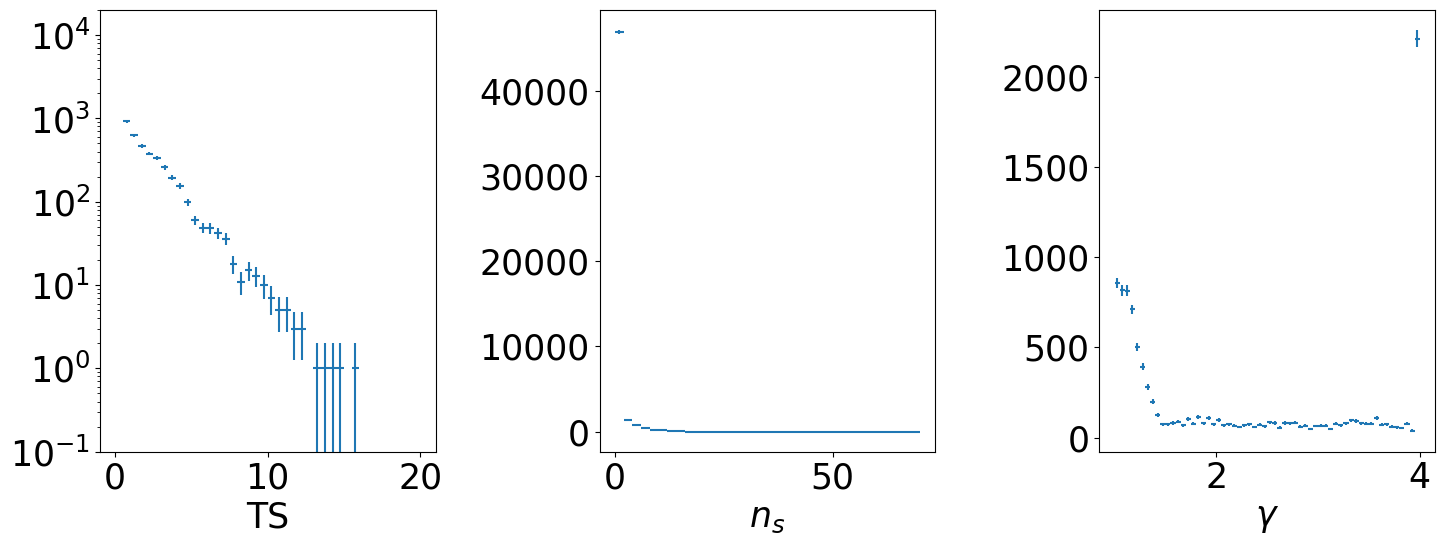

In [23]:

fig, axs = plt.subplots(1, 3, figsize=(15,6))

if source_mdl_used=="PL":
    h_gamma = hl.hist(bkg_gamma[bkg_ns > 0], bins=np.r_[1:4.01:.05])
else:
    h_epeak = hl.hist(bkg_epeak[bkg_ns > 0], bins=np.r_[3:10.01:.1])

h_ts = hl.hist(bkg_ts, bins=np.r_[:20.1:.5])
h_ns = hl.hist(bkg_ns, bins=np.r_[:70.1:2])

hl.plot1d(axs[0], h_ts, crosses=True)
hl.plot1d(axs[1], h_ns, crosses=True)
if source_mdl_used=="PL":
    hl.plot1d(axs[2], h_gamma, crosses=True)
    axs[2].set_xlabel(r'$\gamma$')
else:
    hl.plot1d(axs[2], h_epeak, crosses=True)
    axs[2].set_xlabel(r'E$_{peak}$')

axs[0].set_xlabel("TS")
axs[1].set_xlabel(r'$n_s$')



axs[0].set_ylim(1e-1, 2e4)
axs[0].semilogy()
#axs[1].semilogy()
plt.tight_layout()
if kde_used==True:
    plt.savefig(f'Image_plots/{name_used}/bkg_TS_ns_g_dist_{num_trials}_trials_sig_with_kde.png')
else:
    plt.savefig(f'Image_plots/{name_used}/bkg_TS_ns_g_dist_{num_trials}_trials_sig_no_kde.png')


### Next calculate sensitivity

In [24]:
from skyllh.core.utils.analysis import estimate_sensitivity,estimate_discovery_potential 

rss = RandomStateService(seed=2)

In [25]:
if source_tested[0]=='Code_test':
    energy_bins = np.logspace(3,9,5)
else:
    energy_bins = np.logspace(3,9,13)
energy_bins

array([1.00000000e+03, 3.16227766e+03, 1.00000000e+04, 3.16227766e+04,
       1.00000000e+05, 3.16227766e+05, 1.00000000e+06, 3.16227766e+06,
       1.00000000e+07, 3.16227766e+07, 1.00000000e+08, 3.16227766e+08,
       1.00000000e+09])

## Running Signal Trials!

In [26]:
# Fixing Gamma for signal Injection
print(ana.pmm)
gps = ana.pmm._global_paramset
try:
    gps.make_params_fixed({'gamma': 2.0})
except:
    print("Gamma should be fixed, check")
print(ana.pmm)

ParameterModelMapper: 2 global parameters, 2 models (1 source)
    Parameters:        
        ns [floating (0 <= 100 <= 1000)]
            in models:
            - IceCube: ns
                    
        gamma [floating (1 <= 2 <= 4)]
            in models:
            - SN1006: gamma
            
ParameterModelMapper: 2 global parameters, 2 models (1 source)
    Parameters:        
        ns [floating (0 <= 100 <= 1000)]
            in models:
            - IceCube: ns
                    
        gamma [fixed (2)]
            in models:
            - SN1006: gamma
            


In [27]:
sig_trials_directory = f'Cache/{name_used}_trials_gamma_{spectral_index}/'
sig_data_directory = f'Data_files/{name_used}/sig_trials_gamma_{spectral_index}/'

os.makedirs(sig_trials_directory, exist_ok=True)
os.makedirs(sig_data_directory, exist_ok=True)

ns_list = [1,2,5,7,10,12,15,20,25,30,60]
if source_tested[0]=='Code_test':
    n_trials = 200
else:
    n_trials = 500

def create_job(args):
    #global ANA_WORKER
    emin_used, emax_used, n_sig = args
    
    filename = f'sens_sig_trials_{emin_used}_{emax_used}_n_sig_{n_sig}.npy'
    cache_path = f'{sig_trials_directory}/{filename}'
    final_path = f'{sig_data_directory}/{filename}'
    lock_path  = cache_path + ".lock"
    
    if os.path.isfile(final_path):
        return f"SKIP {filename}"
    if os.path.isfile(cache_path):
        return f"EXISTS {filename}"

    try:
        fd = os.open(lock_path, os.O_CREAT | os.O_EXCL | os.O_WRONLY)
        os.close(fd)
    except FileExistsError:
        return f"SKIP locked {filename}"
        
    try:
        # IMPORTANT: make a local copy of ana as we are changing emin and emax
        ANA_WORKER = get_ana()
        if ANA_WORKER is None:
            ANA_WORKER = make_ana(cfg, datasets, source,
                                   E_refrence_val, spectral_index,
                                   kde_used, minimizer_used)
        ANA_WORKER.energy_range = (emin_used, emax_used)

        if os.path.isfile(cache_path):
            trials = np.load(cache_path)
            return f"EXISTS {filename}"
        else:
            create_trial_data_file(
                ana=ANA_WORKER,
                rss=rss,
                n_trials=10,
                mean_n_sig=float(n_sig),
                pathfilename=cache_path,
                ncpu=1,   # IMPORTANT: avoid nested parallelism
                tl=tl
            )
            trials = np.load(cache_path)
            return f"CREATED {filename}"
    except Exception as e:
        #if isinstance(e, ZeroDivisionError):
        trials = np.asarray([spectral_index, float(n_sig), 0., 0., 0.,  0., 0.])
        np.save(cache_path,trials)
        return f"FAILED CREATE {filename}: {e}\n Added 0,0 array"
        #return f"FAILED CREATE {filename}: {e}"
    finally:
        # remove lock
        if os.path.exists(lock_path):
            os.remove(lock_path)

def extend_job(args):
    #global ANA_WORKER
    emin, emax, n_sig = args
    filename = f'sens_sig_trials_{emin}_{emax}_n_sig_{n_sig}.npy'
    cache_path = f'{sig_trials_directory}/{filename}'
    final_path = f'{sig_data_directory}/{filename}'
    lock_path  = cache_path + ".lock"
    
        
    if os.path.isfile(final_path):
        return f"DONE {filename}"

    if not os.path.isfile(cache_path):
        return f"WAITING {filename}"

    try:
        fd = os.open(lock_path, os.O_CREAT | os.O_EXCL | os.O_WRONLY)
        os.close(fd)
    except FileExistsError:
        return f"SKIP locked {filename}"

    try:
        trials = np.load(cache_path)

        if len(trials) >= n_trials:
            os.replace(cache_path, final_path)
            return f"MOVED {filename}"

        ANA_WORKER = get_ana()
        
        if ANA_WORKER is None:
            ANA_WORKER = make_ana(cfg, datasets, source,
                                   E_refrence_val, spectral_index,
                                   kde_used, minimizer_used)
        ANA_WORKER.energy_range = (emin, emax)

        extend_trial_data_file(
                    ana=ANA_WORKER,
                    rss=rss,
                    n_trials=100,
                    mean_n_sig=float(n_sig),
                    trial_data=trials,
                    pathfilename=cache_path,
                    ncpu=1,
                    tl=tl
                )
        trials = np.load(cache_path)
        return f"EXTENDED {filename} ({len(trials)})"
    except Exception as e:
        return f"FAILED EXTEND {filename}: {e}"
    finally:
        # remove lock
        if os.path.exists(lock_path):
            os.remove(lock_path)



In [28]:
jobs = []

ANA_CACHE = {}
ANA_WORKER = None
def get_ana():
    pid = os.getpid()

    if pid not in ANA_CACHE:
        ANA_CACHE[pid] = make_ana(cfg, datasets, source,
                                  E_refrence_val, spectral_index,
                                  kde_used, minimizer_used)

    return ANA_CACHE[pid]
    
#def init_worker(cfg, datasets, source, E_refrence_val, spectral_index, kde_used, minimizer_used):
#    global ANA_WORKER
#    ANA_WORKER = make_ana(cfg, datasets, source, E_refrence_val, spectral_index, kde_used, minimizer_used)


    
for i in range(1, len(energy_bins)):
    emin = energy_bins[i-1]
    emax = energy_bins[i]
    if emin >= 100000000.0:
        continue

    
    
    print(f"\n=== ENERGY BIN {emin} - {emax} ===")
    jobs = [(emin, emax, n_sig) for n_sig in ns_list]

    # -----------------------------
    # PHASE 1: CREATE (parallel)
    # -----------------------------
    with ProcessPoolExecutor(max_workers=12) as executor:
        results = list(executor.map(create_job, jobs))
    for r in results:
        print(r)

# -----------------------------
# PHASE 2: EXTEND (loop until all done)
# -----------------------------
extend_jobs = []
for i in range(1, len(energy_bins)):
    emin = energy_bins[i-1]
    emax = energy_bins[i]
    if emin >= 100000000.0:
        continue

    
    
    print(f"\n=== ENERGY BIN {emin} - {emax} ===")
    jobs = [(emin, emax, n_sig) for n_sig in ns_list]
    
    for emin, emax, n_sig in jobs:
        filename = f'sens_sig_trials_{emin}_{emax}_n_sig_{n_sig}.npy'
        cache_path = f'{sig_trials_directory}/{filename}'

        # only extend if file exists
        if os.path.isfile(cache_path):
            extend_jobs.append((emin, emax, n_sig))
        
done = False

while not done:

    with ProcessPoolExecutor(max_workers=4) as executor:
        results = list(executor.map(extend_job, extend_jobs))

    new_extend_jobs = []

    for job, r in zip(extend_jobs, results):
        print(r)
        
        if "MOVED" in r or "DONE" in r:
            continue
        elif "FAILED" in r:
            print(f"GIVING UP on {job} ")

   
        elif "EXTENDED" in r:
            new_extend_jobs.append(job)
        elif "SKIP" in r or "locked" in r:
            continue
        else:
            retry_count[job[2]] += 1

            if retry_count[job[2]] < MAX_RETRIES:
                new_extend_jobs.append(job)
            else:
                print(f"Unknown state, dropping {job}")
    extend_jobs = new_extend_jobs
    done = len(extend_jobs) == 0


=== ENERGY BIN 1000.0 - 3162.2776601683795 ===
SKIP sens_sig_trials_1000.0_3162.2776601683795_n_sig_1.npy
SKIP sens_sig_trials_1000.0_3162.2776601683795_n_sig_2.npy
SKIP sens_sig_trials_1000.0_3162.2776601683795_n_sig_5.npy
SKIP sens_sig_trials_1000.0_3162.2776601683795_n_sig_7.npy
SKIP sens_sig_trials_1000.0_3162.2776601683795_n_sig_10.npy
SKIP sens_sig_trials_1000.0_3162.2776601683795_n_sig_12.npy
SKIP sens_sig_trials_1000.0_3162.2776601683795_n_sig_15.npy
SKIP sens_sig_trials_1000.0_3162.2776601683795_n_sig_20.npy
SKIP sens_sig_trials_1000.0_3162.2776601683795_n_sig_25.npy
SKIP sens_sig_trials_1000.0_3162.2776601683795_n_sig_30.npy
SKIP sens_sig_trials_1000.0_3162.2776601683795_n_sig_60.npy

=== ENERGY BIN 3162.2776601683795 - 10000.0 ===
SKIP sens_sig_trials_3162.2776601683795_10000.0_n_sig_1.npy
SKIP sens_sig_trials_3162.2776601683795_10000.0_n_sig_2.npy
SKIP sens_sig_trials_3162.2776601683795_10000.0_n_sig_5.npy
SKIP sens_sig_trials_3162.2776601683795_10000.0_n_sig_7.npy
SKIP se

In [29]:
broken = []
incomplete = []
missing = []


for i in range(1, len(energy_bins)):
    emin = energy_bins[i-1]
    emax = energy_bins[i]
    if emin >= 100000000.0:
        continue
    jobs = [(emin, emax, n_sig) for n_sig in ns_list]
    for emin, emax, n_sig in jobs:
        filename = f'sens_sig_trials_{emin}_{emax}_n_sig_{n_sig}.npy'
        cache_path = f'{sig_trials_directory}/{filename}'
        final_path = f'{sig_data_directory}/{filename}'
    
        if not os.path.isfile(cache_path):
            missing.append((emin, emax, n_sig))
            continue

        try:
            data = np.load(final_path)

            if len(data) >= n_trials:
                complete.append((emin, emax, n_sig))
            else:
                incomplete.append((emin, emax, n_sig))

        except Exception:
            broken.append((emin, emax, n_sig))

print("Incomplete:", len(incomplete))
print("Broken:", len(broken))
print("Missing:", len(missing))


create_jobs = missing + broken
extend_jobs = incomplete
with ProcessPoolExecutor(max_workers=8) as executor:
    results = list(executor.map(create_job, create_jobs))
extend_jobs = []
for i in range(1, len(energy_bins)):
    emin = energy_bins[i-1]
    emax = energy_bins[i]
    if emin >= 100000000.0:
        continue

    
    
    print(f"\n=== ENERGY BIN {emin} - {emax} ===")
    jobs = [(emin, emax, n_sig) for n_sig in ns_list]
    
    for emin, emax, n_sig in jobs:
        filename = f'sens_sig_trials_{emin}_{emax}_n_sig_{n_sig}.npy'
        cache_path = f'{sig_trials_directory}/{filename}'

        # only extend if file exists
        if os.path.isfile(cache_path):
            extend_jobs.append((emin, emax, n_sig))
with ProcessPoolExecutor(max_workers=8) as executor:
    results = list(executor.map(extend_job, extend_jobs))

for r in results:
    print(r)

Incomplete: 0
Broken: 0
Missing: 110

=== ENERGY BIN 1000.0 - 3162.2776601683795 ===

=== ENERGY BIN 3162.2776601683795 - 10000.0 ===

=== ENERGY BIN 10000.0 - 31622.776601683792 ===

=== ENERGY BIN 31622.776601683792 - 100000.0 ===

=== ENERGY BIN 100000.0 - 316227.7660168379 ===

=== ENERGY BIN 316227.7660168379 - 1000000.0 ===

=== ENERGY BIN 1000000.0 - 3162277.6601683795 ===

=== ENERGY BIN 3162277.6601683795 - 10000000.0 ===

=== ENERGY BIN 10000000.0 - 31622776.60168379 ===

=== ENERGY BIN 31622776.60168379 - 100000000.0 ===


In [30]:
for i in range(1, len(energy_bins)):
    emin = energy_bins[i-1]
    emax = energy_bins[i]
    if emin >= 100000000.0:
        continue
    jobs = [(emin, emax, n_sig) for n_sig in ns_list]
    for emin, emax, n_sig in jobs:
        filename = f'sens_sig_trials_{emin}_{emax}_n_sig_{n_sig}.npy'
        cache_path = f'{sig_trials_directory}/{filename}'
        final_path = f'{sig_data_directory}/{filename}'
    
        if not os.path.isfile(final_path):
            os.system(f'mv {cache_path} {final_path}')
            continue

### DONE RUNNING TRIALS!

In [31]:
# Freeing Gamma again
print(ana.pmm)
gps = ana.pmm._global_paramset
try:
    gps.make_params_fixed({'gamma': 2.0})
except:
    print("Gamma should be fixed, check")
print(ana.pmm)

ParameterModelMapper: 2 global parameters, 2 models (1 source)
    Parameters:        
        ns [floating (0 <= 100 <= 1000)]
            in models:
            - IceCube: ns
                    
        gamma [fixed (2)]
            in models:
            - SN1006: gamma
            
Gamma should be fixed, check
ParameterModelMapper: 2 global parameters, 2 models (1 source)
    Parameters:        
        ns [floating (0 <= 100 <= 1000)]
            in models:
            - IceCube: ns
                    
        gamma [fixed (2)]
            in models:
            - SN1006: gamma
            


## Calculating Sensitivity and DP

In [32]:
from scipy.interpolate import interp1d

In [33]:
ana.energy_range = (1e2,1e9)

In [34]:
from scipy.stats import norm

In [35]:
energy_bins

array([1.00000000e+03, 3.16227766e+03, 1.00000000e+04, 3.16227766e+04,
       1.00000000e+05, 3.16227766e+05, 1.00000000e+06, 3.16227766e+06,
       1.00000000e+07, 3.16227766e+07, 1.00000000e+08, 3.16227766e+08,
       1.00000000e+09])

In [36]:
# Load Bkg trials
bkg_trials = np.load(f'{data_directory}/bkg_trials_gamma_{spectral_index}.npy')
ts_bkg = bkg_trials['ts']
ts_threshold = np.median(ts_bkg)


p_5sigma = 1 - norm.cdf(5)
p_3sigma = 1 - norm.cdf(3)
ts_5sigma = np.quantile(ts_bkg, 1 - p_5sigma)
ts_3sigma = np.quantile(ts_bkg, 1 - p_3sigma)

print("TS_5sigma =", ts_5sigma)
print("TS_3sigma =", ts_3sigma)
print("Median background TS =", ts_threshold)

#Load Sensitivity
sensitivity = []
gamma_vals =[]
dp_5=[]
dp_3=[]
skip = []
skipping=False
for i in range(1, len(energy_bins)):
    emin = energy_bins[i-1]
    emax = energy_bins[i]
    if emin >= 100000000.0:
        continue
    
    ns_vals=[]
    probs=[]
    dp_3_probs=[]
    dp_5_probs=[]
    for indi_signal_value in ns_list: 
    
        trials = np.load(f'{sig_data_directory}/sens_sig_trials_{emin}_{emax}_n_sig_{indi_signal_value}.npy')
        try:
            injected_ns = trials['mean_n_sig'][0]
        except Exception as e:
            if isinstance(e,IndexError):
                skip.append([indi_signal_value,emin,emax])
                print("Skipping", indi_signal_value,emin,"-",emax)
                skipping=True
                continue
        ts = trials['ts']

        prob = np.mean(ts > ts_threshold)

        ns_vals.append(injected_ns)
        probs.append(prob)

        dp_5_prob = np.mean(ts > ts_5sigma)
        dp_5_probs.append(dp_5_prob)
        dp_3_prob = np.mean(ts > ts_3sigma)
        dp_3_probs.append(dp_3_prob)

        print(injected_ns, prob,dp_3_prob,dp_5_prob)
    if skipping==True:
        skipping=False
        continue

        
    

    ns_vals = np.array(ns_vals)
    probs = np.array(probs)

    interp = interp1d(probs, ns_vals)

    dp_3_interp = interp1d(dp_3_probs, ns_vals, kind='linear', fill_value='extrapolate')
    dp_5_interp = interp1d(dp_5_probs, ns_vals, kind='linear', fill_value='extrapolate')
    
    try: 
        ns_disc_5 = dp_5_interp(0.5)
    except:
        print(f'bin {emin} - {emax}',"5sig DP not found")
        dp_5.append(0.1)
    else:
        print(f'Running bin {emin} - {emax}')
        print("5 sigma Discovery potential (ns) =", ns_disc_5)
        dp_5.append(ns_disc_5)
        
    try: 
        ns_disc_3 = dp_3_interp(0.5)
    except:
        print(f'bin {emin} - {emax}',"DP not found")
        dp_3.append(0.1)
    else:
        print(f'Running bin {emin} - {emax}')
        print("Discovery potential (ns) =", ns_disc_3)
        dp_3.append(ns_disc_3)


    try: 
        ns_sensitivity = interp(0.9)
    except:
        print(f'bin {emin} - {emax}',"Sens not found")
        sensitivity.append(0.1)
    else:
        print(f'Running bin {emin} - {emax}')
        print("Sensitivity =", ns_sensitivity)
        sensitivity.append(ns_sensitivity)
    

    #print(ns_vals,probs)

TS_5sigma = 15.793279843320166
TS_3sigma = 8.447723343437257
Median background TS = 0.0
Skipping 1 1000.0 - 3162.2776601683795
Skipping 2 1000.0 - 3162.2776601683795
Skipping 5 1000.0 - 3162.2776601683795
Skipping 7 1000.0 - 3162.2776601683795
Skipping 10 1000.0 - 3162.2776601683795
Skipping 12 1000.0 - 3162.2776601683795
Skipping 15 1000.0 - 3162.2776601683795
Skipping 20 1000.0 - 3162.2776601683795
Skipping 25 1000.0 - 3162.2776601683795
Skipping 30 1000.0 - 3162.2776601683795
Skipping 60 1000.0 - 3162.2776601683795
Skipping 1 3162.2776601683795 - 10000.0
Skipping 2 3162.2776601683795 - 10000.0
Skipping 5 3162.2776601683795 - 10000.0
Skipping 7 3162.2776601683795 - 10000.0
Skipping 10 3162.2776601683795 - 10000.0
Skipping 12 3162.2776601683795 - 10000.0
Skipping 15 3162.2776601683795 - 10000.0
Skipping 20 3162.2776601683795 - 10000.0
Skipping 25 3162.2776601683795 - 10000.0
Skipping 30 3162.2776601683795 - 10000.0
Skipping 60 3162.2776601683795 - 10000.0
Skipping 1 10000.0 - 31622.77

In [37]:
sensitivity

[array(21.75),
 array(24.05172414),
 array(24.46969697),
 array(21.17647059),
 array(13.02631579),
 array(4.94),
 array(4.4)]

In [38]:
flux_sensitivity = np.asarray(sensitivity)
flux_dp_3 = np.asarray(dp_3)
flux_dp_5 = np.asarray(dp_5)
all_res = []
energy_centers = []
emin_error = []
emax_error = []
skipping = False
sens_index = 0
for i in range(1, len(energy_bins)):
    emin = energy_bins[i-1]
    emax = energy_bins[i]
    if emin >= 100000000.0:
        continue
    for skip_arr in skip:
        if emin ==skip_arr[1] and emax ==skip_arr[2]:
            skipping=True
            continue
    if skipping==True:
        skipping=False
        continue
                

    energy_centers.append(10**(0.5 * (np.log10(emin) +np.log10(emax))))
    emin_error.append(((10**(0.5 * (np.log10(emin) +np.log10(emax)))-emin)/1e3))
    emax_error.append((emax-10**(0.5 * (np.log10(emin) +np.log10(emax))))/1e3)


    ana.energy_range = (emin,emax)
    
    print(ana.calculate_fluxmodel_scaling_factor(),sensitivity[sens_index])
    #flux_sensitivity[i-1] = ana.calculate_fluxmodel_scaling_factor()*sensitivity[i-1]
    flux_sensitivity[sens_index] = ana.mu2flux(sensitivity[sens_index])

    #flux_dp[i-1] = ana.calculate_fluxmodel_scaling_factor()*dp[i-1]
    flux_dp_5[sens_index] = ana.mu2flux(dp_5[sens_index])
    flux_dp_3[sens_index] = ana.mu2flux(dp_3[sens_index])

    all_res.append([emin,emax,flux_sensitivity[sens_index],flux_dp_3[sens_index],flux_dp_5[sens_index]])

    sens_index+=1

    # FLux is ins GeV-1 cm-2 s-1 sr-1
    # But str deltafunction normalizes to 1 so that can be removed by multiplying 1
    # If the reference energy used is 1 TeV, then multiplying by 1e3 changes the units to TeV and then multiplying by E^2 where E is 1 TeV should give E2dn/de

np.save(f'{data_directory}/sensitivity_dp_results_{spectral_index}.npy',all_res)

energy_centers = np.asarray(energy_centers)
emin_error = np.asarray(emin_error)
emax_error = np.asarray(emax_error)


1.3053815702298588e-13 21.750000000000004
1.2897634849192622e-14 24.05172413793104
4.968507269342328e-15 24.469696969696972
3.753734435290476e-15 21.176470588235297
5.1770999829955625e-15 13.026315789473685
8.398243311460322e-15 4.9399999999999995
1.6090661656571227e-14 4.4


In [39]:
energy_centers

array([   56234.13251903,   177827.94100389,   562341.32519035,
        1778279.41003892,  5623413.25190349, 17782794.10038923,
       56234132.51903491])

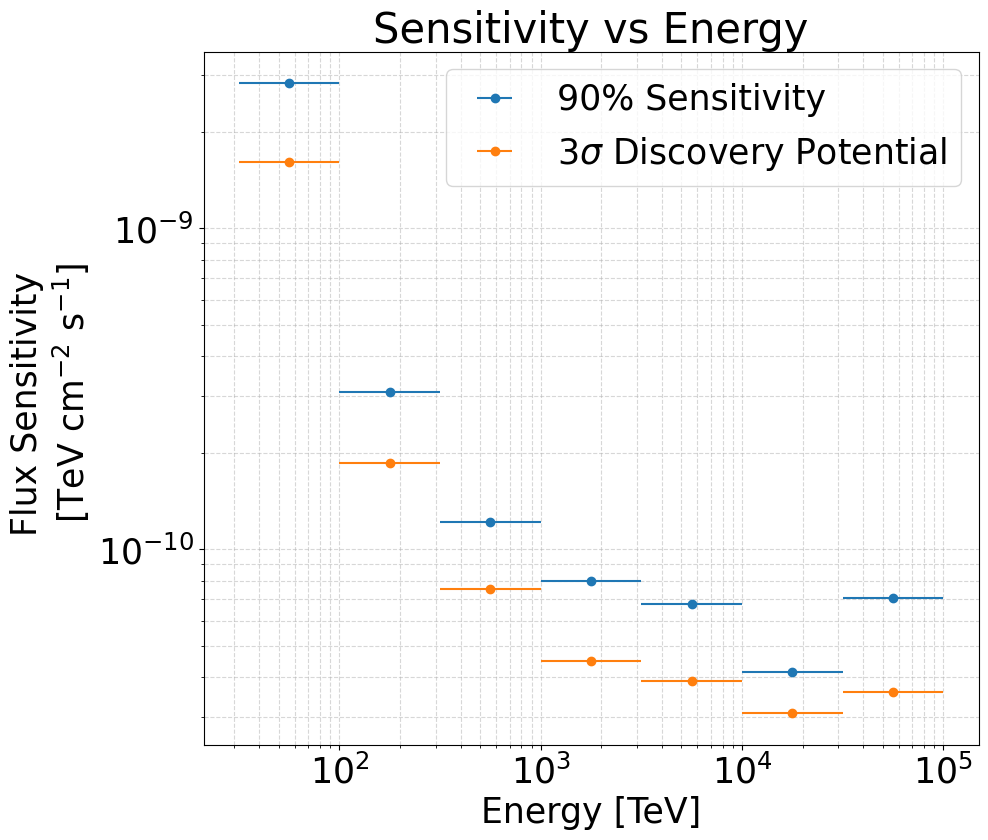

In [40]:

plt.figure(figsize=(10,9))
plt.errorbar(energy_centers/1e3, flux_sensitivity*1e3, xerr=np.asarray([emin_error,emax_error]), marker='o', linestyle='',label="90% Sensitivity")
plt.errorbar(energy_centers/1e3, flux_dp_3*1e3, xerr=np.asarray([emin_error,emax_error]), marker='o', linestyle='',label=r"3$\sigma$ Discovery Potential")
#plt.errorbar(energy_centers/1e3, flux_dp_5*1e3, xerr=np.asarray([emin_error,emax_error]), marker='o', linestyle='',label=r"5$\sigma$ Discovery Potential")
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy [TeV]')
plt.ylabel('Flux Sensitivity \n [TeV cm$^{-2}$ s$^{-1}$]')
plt.title('Sensitivity vs Energy')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.savefig(f'Image_plots/{name_used}/sensitivity_flux_vs_e.png',bbox_inches="tight")
plt.show()

        

In [41]:
energy_centers-emin

array([-3.16171532e+08, -3.16049938e+08, -3.15665425e+08, -3.14449487e+08,
       -3.10604353e+08, -2.98444972e+08, -2.59993633e+08])

In [42]:
os.getcwd()

'/Users/aadesai1/Desktop/In_use/public_IceCube_data/justin_paper_checks'

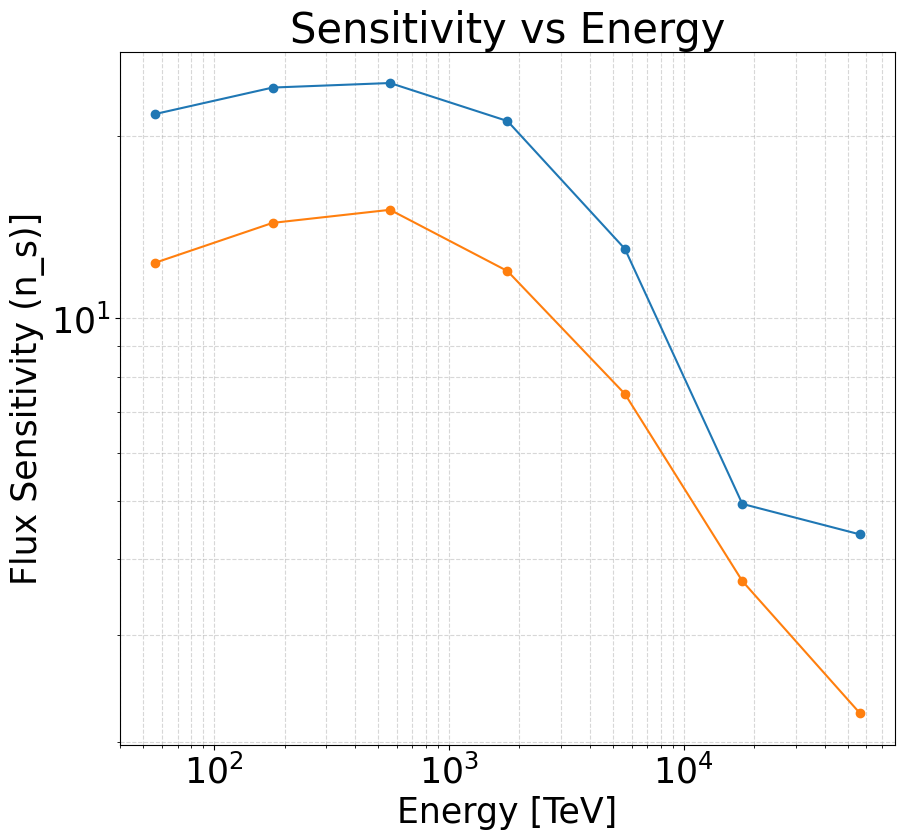

In [43]:
plt.figure(figsize=(10,9))
plt.plot(energy_centers/1e3, sensitivity, marker='o', linestyle='-',label=r"90% Sensitivity")
plt.plot(energy_centers/1e3, dp_3, marker='o', linestyle='-',label=r"3$\sigma$ Discovery Potential")
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy [TeV]')
plt.ylabel('Flux Sensitivity (n_s)]')
plt.title('Sensitivity vs Energy')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.savefig(f'Image_plots/{name_used}/sensitivity_ns_vs_e.png',bbox_inches="tight")
plt.show()

# If using Test Code for Sensitivity and DP, Stop analysis here

In [70]:
# Freeing Gamma again
print(ana.pmm)
gps = ana.pmm._global_paramset
try:
    gps.make_params_floating({'gamma': 2.0})
except:
    print("Gamma should be free, check")
print(ana.pmm)

ParameterModelMapper: 2 global parameters, 2 models (1 source)
    Parameters:        
        ns [floating (0 <= 100 <= 1000)]
            in models:
            - IceCube: ns
                    
        gamma [floating (1 <= 2 <= 4)]
            in models:
            - SN1006: gamma
            
Gamma should be free, check
ParameterModelMapper: 2 global parameters, 2 models (1 source)
    Parameters:        
        ns [floating (0 <= 100 <= 1000)]
            in models:
            - IceCube: ns
                    
        gamma [floating (1 <= 2 <= 4)]
            in models:
            - SN1006: gamma
            


In [71]:
ana.energy_range = (1e2,1e9)

### Initializing a trial

After the Analysis instance was created trials can be run. To do so the analysis needs to be initialized with some trial data. For instance we could initialize the analysis with the experimental data to “unblind” the analysis afterwards. Technically the TrialDataManager of each log-likelihood ratio function, i.e. dataset, is initialized with data.

The Analysis class provides the method initialize_trial to initialize a trial with data. It takes a list of DataFieldRecordArray instances holding the events. If we want to initialize a trial with the experimental data, we can get that list from the Analysis instance itself:

In [72]:
events_list = [ data.exp for data in ana.data_list ]
ana.initialize_trial(events_list)

### Maximizing the log-likelihood ratio function

After initializing a trial, we can maximize the LLH ratio function using the maximize_llhratio method of the Analysis class. This method requires a RandomStateService instance in case the minimizer does not succeed and a new set of initial values for the fit parameters need to get generated. The method returns a 4-element tuple. The first element is the set of fit parameters used in the maximization. The second element is the value of the LLH ration function at its maximum. The third element is the array of the fit parameter values at the maximum, and the forth element is the status dictionary of the minimizer.

In [73]:
rss=RandomStateService(seed=2)

In [74]:
(log_lambda_max, fitparam_values, status) = ana.llhratio.maximize(rss)

ValueError: The gflp_values argument is of length 2, but must be of length 1!

In [ ]:
print(f'log_lambda_max = {log_lambda_max}')
print(f'fitparam_values = {fitparam_values}')
print(f'status = {status}')

In [75]:
TS = ana.calculate_test_statistic(log_lambda_max, fitparam_values)
print(f'TS = {TS:.3f}')

TS = 0.000


### Unblinding the data and Getting Best Fit Values! 

After creating the analysis instance we can unblind the data for the choosen source. Hence, we initialize the analysis with a trial of the experimental data, maximize the log-likelihood ratio function for all given experimental data events, and calculate the test-statistic value. The analysis instance has the method unblind that can be used for that. 

In [51]:
#help(ana.unblind)

In [52]:
(ts, x, status) = ana.unblind(minimizer_rss=rss)
print(ts, x, status)

0.0 {'ns': 0.0, 'gamma': 1.0} {'grad': array([ 0.83705165, -0.        ]), 'task': 'CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL', 'funcalls': 11, 'nit': 9, 'warnflag': 0, 'skyllh_minimizer_n_reps': 0, 'n_llhratio_func_calls': 11}


In [53]:
print(f'TS = {ts:.3f}')
print(f'ns = {x["ns"]:.2f}')
if source_mdl_used=="PL":
    print(f'gamma = {x["gamma"]:.2f}')
else:
    print(f'e_peak = {x["e_peak"]:.2f}')
    

TS = 0.000
ns = 0.00
gamma = 1.00


In [54]:
x

{'ns': 0.0, 'gamma': 1.0}

In [55]:
scipy.stats.chi2.ppf(0.68, df=2)

2.27886856637673

In [56]:
bkg_trials = np.load(f'{data_directory}/bkg_trials_gamma_{spectral_index}.npy')


In [57]:
minus_log10_pval = -np.log10(len(bkg_trials[bkg_trials['ts'] > ts]) / len(bkg_trials))
print(f'-log10(p_local) = {minus_log10_pval:.2f}')



-log10(p_local) = 0.94


# Calculating the corresponding flux normalization

By default the analysis is created with a flux normalization of 1 GeV-1s-1cm-2sr-1 
(see refplflux_Phi0 argument of the create_analysis method). 
The analysis instance has the method calculate_fluxmodel_scaling_factor that 
calculates the scaling factor the reference flux normalization has to be 
multiplied with to represent a given analysis result, i.e. and  value. 
This function takes the detected mean  value as first argument and the list of source parameter values as second argument:

In [58]:
if source_mdl_used=="PL":
    scaling_factor = ana.mu2flux(x['ns']) 
else:
    print("To be updated")
print(f'Flux scaling factor = {scaling_factor:.3e}')

Flux scaling factor = 0.000e+00


In [59]:
if source_mdl_used!="PL":
    ana.calculate_fluxmodel_scaling_factor(2, [2000, x['e_peak']])

In [60]:
if source_mdl_used!="PL":
    ana.shg_mgr.get_fluxmodel_by_src_idx(0).energy_profile(E=10**x['e_peak']).squeeze()

In [61]:
if source_mdl_used=="PL":
    print(f'{scaling_factor:.3e}'' (E/1000 GeV)^{-'f'{x["gamma"]:.2f}'+'} 1/(GeV s cm^2 sr)')
    err_lo = ana.mu2flux(x['ns']-15)#ana.calculate_fluxmodel_scaling_factor(x['ns']-15, [x['ns'], x['gamma']])
    err_hi = ana.mu2flux(x['ns']+15)#ana.calculate_fluxmodel_scaling_factor(x['ns']+15, [x['ns'], x['gamma']])
    print(f'{scaling_factor:.3e}+{err_lo:.3e}-{err_hi:.3e} ''(E/1000 GeV)^{-'f'{x["gamma"]:.2f}'+'} 1/(GeV s cm^2 sr)')

else:
    print("To be updated")
    



0.000e+00 (E/1000 GeV)^{-1.00} 1/(GeV s cm^2 sr)
0.000e+00+-1.540e-14-1.540e-14 (E/1000 GeV)^{-1.00} 1/(GeV s cm^2 sr)


In [62]:

with open(f'{data_directory}/results.txt', "w") as f:
    f.write(f"Source Used = {source_tested[0]}\n")
    f.write(f"RA DEC = {source_tested[1]} {source_tested[2]}\n")
    f.write(f"log_lambda_max = {log_lambda_max}\n")
    f.write(f"fitparam_values = {fitparam_values}\n")
    f.write(f"status = {status}\n")
    f.write(f"Unblinding Results (DIFFERENT From Sensitivity and DP which is caluclated for a single index\n")
    f.write(f"TS = {ts:.3f}\n")
    f.write(f'ns = {x["ns"]:.2f}\n')
    f.write(f'gamma = {x["gamma"]:.2f}\n')
    f.write(f'-log10(p_local) = {minus_log10_pval:.2f}\n')
    f.write(f'{scaling_factor:.3e}+{err_lo:.3e}-{err_hi:.3e} (E/1000 GeV)^(-{x["gamma"]:.2f}) 1/(GeV s cm^2 sr)\n')
    f.write(f'\n\n For Differential Sensitivity and DP see numpy file starting with sensitivity_dp_results_ \n')
    f.write(f'The Array is emin, emax, sensitivity, 3sigma DP, 5sigma DP \n')

### Evaluating the log-likelihood ratio function
Sometimes it is useful to be able to evaluate the log-likelihood ratio function, e.g. for creating a likelihood contour plot. Because SkyLLH’s structure is based on the mathematical structure of the likelihood function, the Analysis instance has the property llhratio which is the class instance of the used log-likelihood ratio function. This instance has the method evaluate. The method takes an array of the fit parameter values as argument at which the LLH ratio function will be evaluated. It returns the value of the LLH ratio function at the given point and its gradients w.r.t. the fit parameters.

In our case this is the number of signal events, 
 and the spectral index 
. If we evaluate the LLH ratio function at the maximum, the gradients should be close to zero.



In [63]:
help(ana.llhratio.evaluate)

Help on method evaluate in module skyllh.core.llhratio:

evaluate(fitparam_values, src_params_recarray=None, tl=None) method of skyllh.core.llhratio.MultiDatasetTCLLHRatio instance
    Evaluates the composite log-likelihood-ratio function and returns its
    value and global fit parameter gradients.
    
    Parameters
    ----------
    fitparam_values : instance of numpy ndarray
        The (N_fitparams,)-shaped numpy 1D ndarray holding the current
        values of the global fit parameters.
    src_params_recarray : instance of numpy record ndarray | None
        The numpy record ndarray of length N_sources holding the parameter
        names and values of all sources.
        See the documentation of the
        :meth:`skyllh.core.parameters.ParameterModelMapper.create_src_params_recarray`
        method for more information about this array.
        It case it is ``None``, it will be created automatically from the
        ``fitparam_values`` argument using the
        :class:`~sk

In [64]:

if source_mdl_used=="PL":
    (llhratio_value, (grad_ns, grad_gamma)) = ana.llhratio.evaluate([14.58, 2.17])
    print(f'llhratio_value = {llhratio_value:.3f}')
    print(f'grad_ns = {grad_ns:.3f}')
    print(f'grad_gamma = {grad_gamma:.3f}')
else:
    print("To be updated")

llhratio_value = -5.085
grad_ns = -0.441
grad_gamma = 4.206


In [65]:
fitparam_values

array([0., 1.])

Using the evaluate method of the LLHRatio class we can scan the log-likelihood ratio space and create a contour plot showing the best fit and the 68%, 90%, and 95% quantile assuming Wilks-theorem.



In [66]:
source_mdl_used

'PL'

In [67]:

(ns_min, ns_max, ns_step) = (1, 80, 0.5)
#(ns_min, ns_max, ns_step) = (1, 180, 1.0)
if source_mdl_used=="PL":
    (gamma_min, gamma_max, gamma_step) = (1.5, 4.0, 0.1)
else: 
    print("To be updated")    

ns_edges = np.linspace(ns_min, ns_max, int((ns_max-ns_min)/ns_step)+1)
ns_vals = 0.5*(ns_edges[1:] + ns_edges[:-1])

if source_mdl_used=="PL":
    gamma_edges = np.linspace(gamma_min, gamma_max, int((gamma_max-gamma_min)/gamma_step+1))
    gamma_vals = 0.5*(gamma_edges[1:] + gamma_edges[:-1])
    delta_ts = np.empty((len(ns_vals), len(gamma_vals)), dtype=np.double)
    for (ns_i, ns) in enumerate(ns_vals):
        for (gamma_i, gamma) in enumerate(gamma_vals):
            delta_ts[ns_i, gamma_i] = (
                ana.calculate_test_statistic(llhratio_value, fitparam_values) -
                ana.calculate_test_statistic(ana.llhratio.evaluate([ns, gamma])[0], [ns, gamma])
                )
    # Determine the best fit ns and gamma values from the scan.
    index_max = np.argmin(delta_ts)
    ns_i_max = int(index_max / len(gamma_vals))
    gamma_i_max = index_max % len(gamma_vals)
    ns_best = ns_vals[ns_i_max]
    gamma_best = gamma_vals[gamma_i_max]
else:
    print("To be updated")



In [68]:
# Determine the delta lambda value for the 95% quantile assuming a chi-sqaure
# distribution with 2 degrees of freedom (i.e. assuming Wilks theorem).
if source_mdl_used=="PL":
    df_used = 2
else:
    df_used = 1
chi2_68_quantile = scipy.stats.chi2.ppf(0.68, df=df_used)
chi2_90_quantile = scipy.stats.chi2.ppf(0.90, df=df_used)
chi2_95_quantile = scipy.stats.chi2.ppf(0.95, df=df_used)

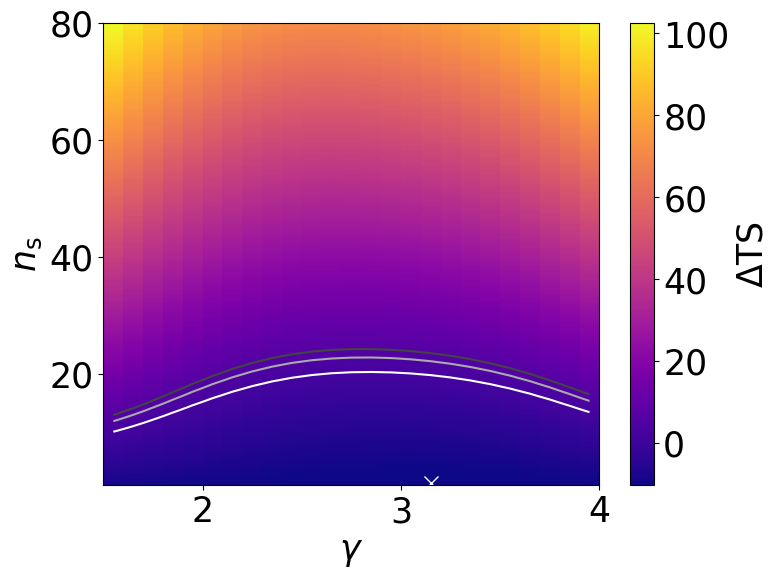

In [69]:

from matplotlib.colors import LogNorm
if source_mdl_used=="PL":
    plt.figure(figsize=(8,6))
    plt.pcolormesh(gamma_edges, ns_edges, delta_ts, cmap='plasma')
    cbar = plt.colorbar()
    cbar.set_label(r'$\Delta$TS')
    plt.contour(gamma_vals, ns_vals, delta_ts, [chi2_68_quantile], colors='#FFFFFF')
    plt.contour(gamma_vals, ns_vals, delta_ts, [chi2_90_quantile], colors='#AAAAAA')
    plt.contour(gamma_vals, ns_vals, delta_ts, [chi2_95_quantile], colors='#444444')
    plt.plot(gamma_best, ns_best, marker='x', color='white', ms=10)
    plt.xlabel(r'$\gamma$')
    plt.ylabel(r'$n_{\mathrm{s}}$')
    plt.ylim(ns_min, ns_max)
    plt.xlim(gamma_min, gamma_max)

    if kde_used==True:
        plt.savefig(f'Image_plots/{name_used}/ns_gamma_likelihood_with_kde.png')
    else:
        plt.savefig(f'Image_plots/{name_used}/ns_gamma_likelihood_no_kde.png')
else:
    print("To be updated")